In [2]:
# LEVEL 1 TASK 1: DATA COLLECTION & WEB SCRAPING
# Dataset Used: books.toscrape.com
# Tools: requests, BeautifulSoup, pandas

# 1. IMPORTING LIBRARIES
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# 2. SET TARGET WEBSITE & HANDLE PAGINATION
base_url = "https://books.toscrape.com/catalogue/page-{}.html"
all_books = []

# We will scrape first 5 pages = 100 books
for page in range(1, 6):
    url = base_url.format(page)
    print(f"Scraping: {url}")

    # Send request to website
    response = requests.get(url)

    # Check if request was successful
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all books on the page
        books = soup.find_all('article', class_='product_pod')

        # 3. EXTRACT DATA FROM EACH BOOK
        for book in books:
            title = book.h3.a['title']
            price = book.find('p', class_='price_color').text.replace('£', '')
            availability = book.find('p', class_='instock availability').text.strip()
            rating = book.find('p', class_='star-rating')['class'][1] # One, Two, Three etc

            all_books.append({
                'Title': title,
                'Price_GBP': price,
                'Availability': availability,
                'Rating': rating
            })
    else:
        print(f"Failed to fetch page {page}")

    time.sleep(1) # Challenge: Be polite, avoid blocking

print(f"\nTotal books scraped: {len(all_books)}")

Scraping: https://books.toscrape.com/catalogue/page-1.html
Scraping: https://books.toscrape.com/catalogue/page-2.html
Scraping: https://books.toscrape.com/catalogue/page-3.html
Scraping: https://books.toscrape.com/catalogue/page-4.html
Scraping: https://books.toscrape.com/catalogue/page-5.html

Total books scraped: 100


In [5]:
# 4. STORE IN STRUCTURED FORMAT: CSV + JSON
df = pd.DataFrame(all_books)

# Clean Price: remove any non-numeric except dot
df['Price_GBP'] = df['Price_GBP'].astype(str).str.replace(r'[^\d.]', '', regex=True)

# Convert Price to float
df['Price_GBP'] = df['Price_GBP'].astype(float)

# Save files
df.to_csv("scraped_books.csv", index=False)
df.to_json("scraped_books.json", orient='records', indent=4)

print("Files saved: scraped_books.csv and scraped_books.json")
df.head(10)

Files saved: scraped_books.csv and scraped_books.json


,Title,Price_GBP,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five
5,The Requiem Red,22.65,In stock,One
6,The Dirty Little Secrets of Getting Your Dream...,33.34,In stock,Four
7,The Coming Woman: A Novel Based on the Life of...,17.93,In stock,Three
8,The Boys in the Boat: Nine Americans and Their...,22.60,In stock,Four
9,The Black Maria,52.15,In stock,One


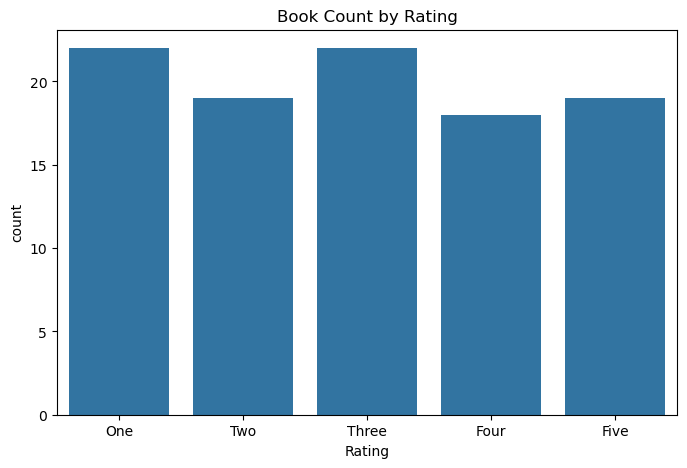


Summary Statistics:
        Price_GBP
count  100.000000
mean    34.560700
std     14.638531
min     10.160000
25%     19.897500
50%     34.775000
75%     47.967500
max     58.110000


In [6]:
# 5. BASIC EDA ON SCRAPED DATA - Bonus for report
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Rating', order=['One','Two','Three','Four','Five'])
plt.title("Book Count by Rating")
plt.show()

print("\nSummary Statistics:")
print(df.describe())

In [7]:
# 6. CONCLUSION / INSIGHTS FOR REPORT
print("""
CONCLUSION:
1. Successfully scraped 100 books from 5 pages using pagination.
2. Handled challenges: Different HTML tags, pagination, rate limiting.
3. Data stored in both CSV and JSON format.
4. Most books have 3-star rating. Average price is around 35 GBP.
""")


CONCLUSION:
1. Successfully scraped 100 books from 5 pages using pagination.
2. Handled challenges: Different HTML tags, pagination, rate limiting.
3. Data stored in both CSV and JSON format.
4. Most books have 3-star rating. Average price is around 35 GBP.

